### Practice Exercise (Linear Regression)

In [6]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import DATASETS_DIR , LN_P

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#loading the dataset
df = pd.read_csv(LN_P)
#exploring the dataset

print(f'Shape of the dataset: {df.shape}')
print(f'Missing value in each column: \n{df.isnull().sum()}')

df.head()

Shape of the dataset: (40, 2)
Missing value in each column: 
HouseSize_sqft    0
Price_USD         0
dtype: int64


,HouseSize_sqft,Price_USD
0,650,72000
1,720,78500
2,800,85000
3,880,91200
4,950,88000


#####  Exploratory Data Analysis (EDA) 

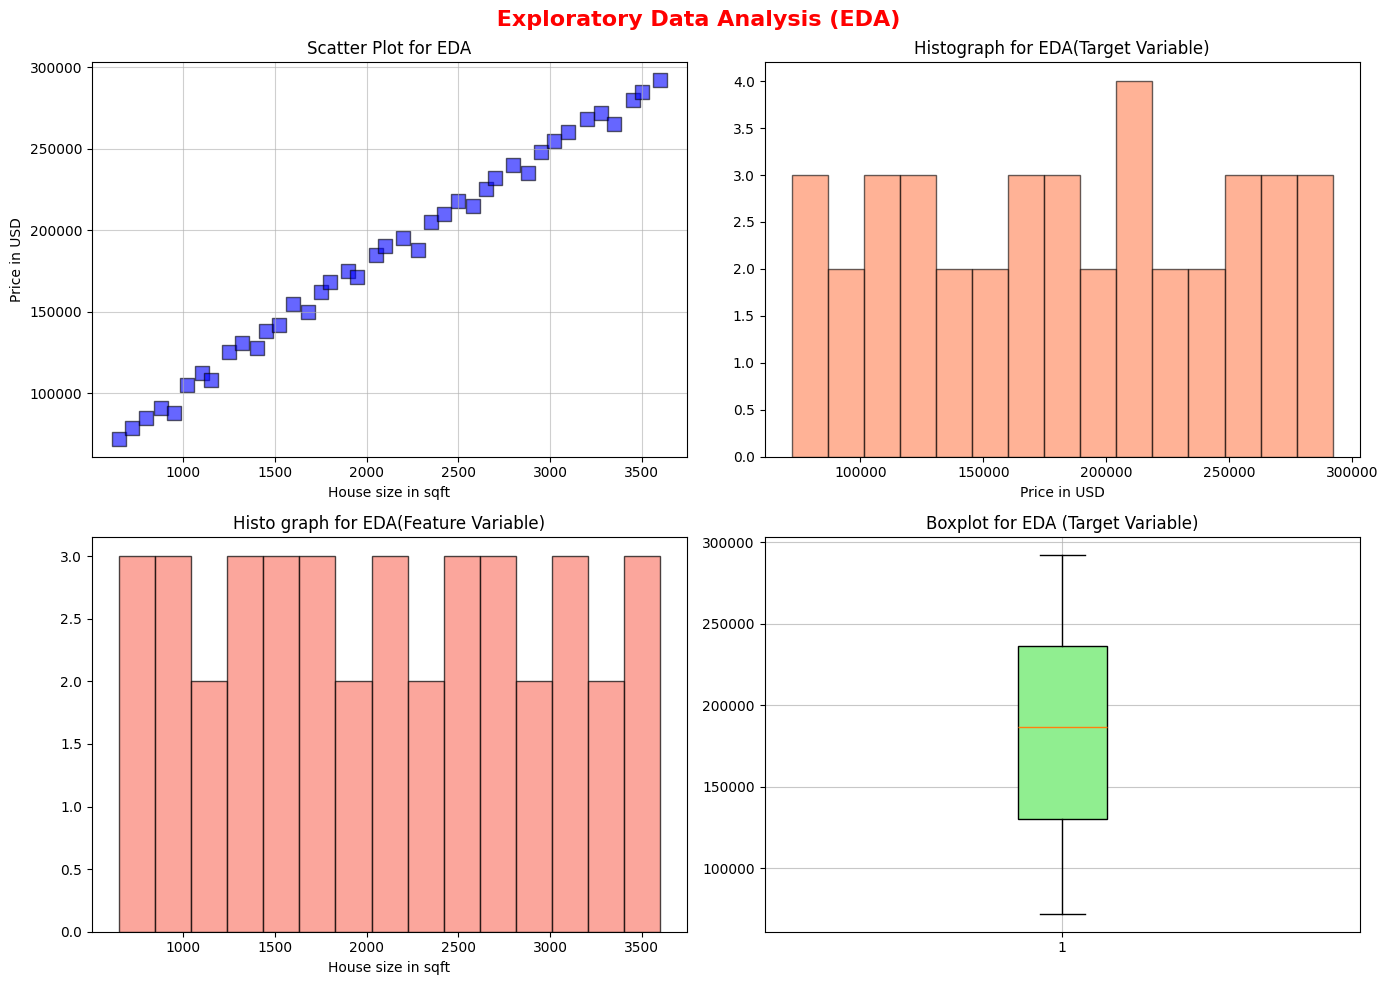

In [27]:
fig , axes = plt.subplots(2,2,figsize=(14,10))
plt.suptitle(' Exploratory Data Analysis (EDA)',fontsize=16, color='r',fontweight='bold')

axes[0,0].scatter(df['HouseSize_sqft'],df['Price_USD'],color='blue',marker=',',s=100,edgecolor='black',alpha=0.6)
axes[0,0].set_ylabel('Price in USD')
axes[0,0].set_xlabel('House size in sqft')
axes[0,0].set_title('Scatter Plot for EDA')
axes[0,0].grid(True,alpha=0.6)

axes[0,1].hist(df['Price_USD'],bins=15,color='coral',alpha=0.6,edgecolor='black')
axes[0,1].set_xlabel('Price in USD')
axes[0,1].set_title('Histograph for EDA(Target Variable)')
# axes[0,1].grid(True,alpha=0.6)


axes[1,0].hist(df['HouseSize_sqft'],color='salmon',alpha=0.7,edgecolor='black',bins=15)
axes[1,0].set_xlabel('House size in sqft')
axes[1,0].set_title('Histo graph for EDA(Feature Variable)')
# axes[1,0].grid(True,alpha=0.6)

axes[1,1].boxplot(df['Price_USD'],patch_artist=True,boxprops=dict(facecolor='lightgreen'))
axes[1,1].grid(True,alpha=0.7)
axes[1,1].set_title('Boxplot for EDA (Target Variable)')


plt.tight_layout()
plt.show()

##### Corelation Heatmap

Corelation between in Dataset : 0.9973


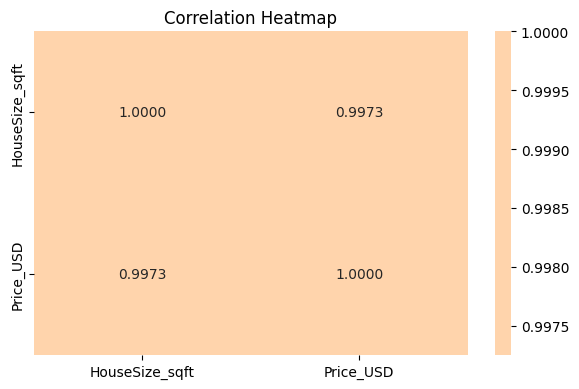

In [38]:
print(f'Corelation between in Dataset : {df['HouseSize_sqft'].corr(df['Price_USD']):.4f}')

import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, center=0, fmt='.4f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### Data Preparation 

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['HouseSize_sqft']]
y = df['Price_USD']


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

ln = LinearRegression()
ln.fit(X_train, y_train)

#making prediction
y_pred_train = ln.predict(X_train)
y_pred_test = ln.predict(X_test)

print(f'Intercept: {ln.intercept_:.4f}')
print(f'Coefficient: {ln.coef_[0]:.4f}')


Intercept: 28691.0095
Coefficient: 73.9953


##### Model Evaluation

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

R2_score = r2_score(y_train, y_pred_train)
mse = mean_absolute_error(y_train,y_pred_train)
mse = np.sqrt(mean_squared_error(y_train,y_pred_train))

print(f'R2_score: {R2_score:.4f}')
print(f'Mean Absolute Error: {mse:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R2_score: 0.9953
Mean Absolute Error: 4574.7821
Mean Squared Error: 4574.7821


##### Result Visualizations 


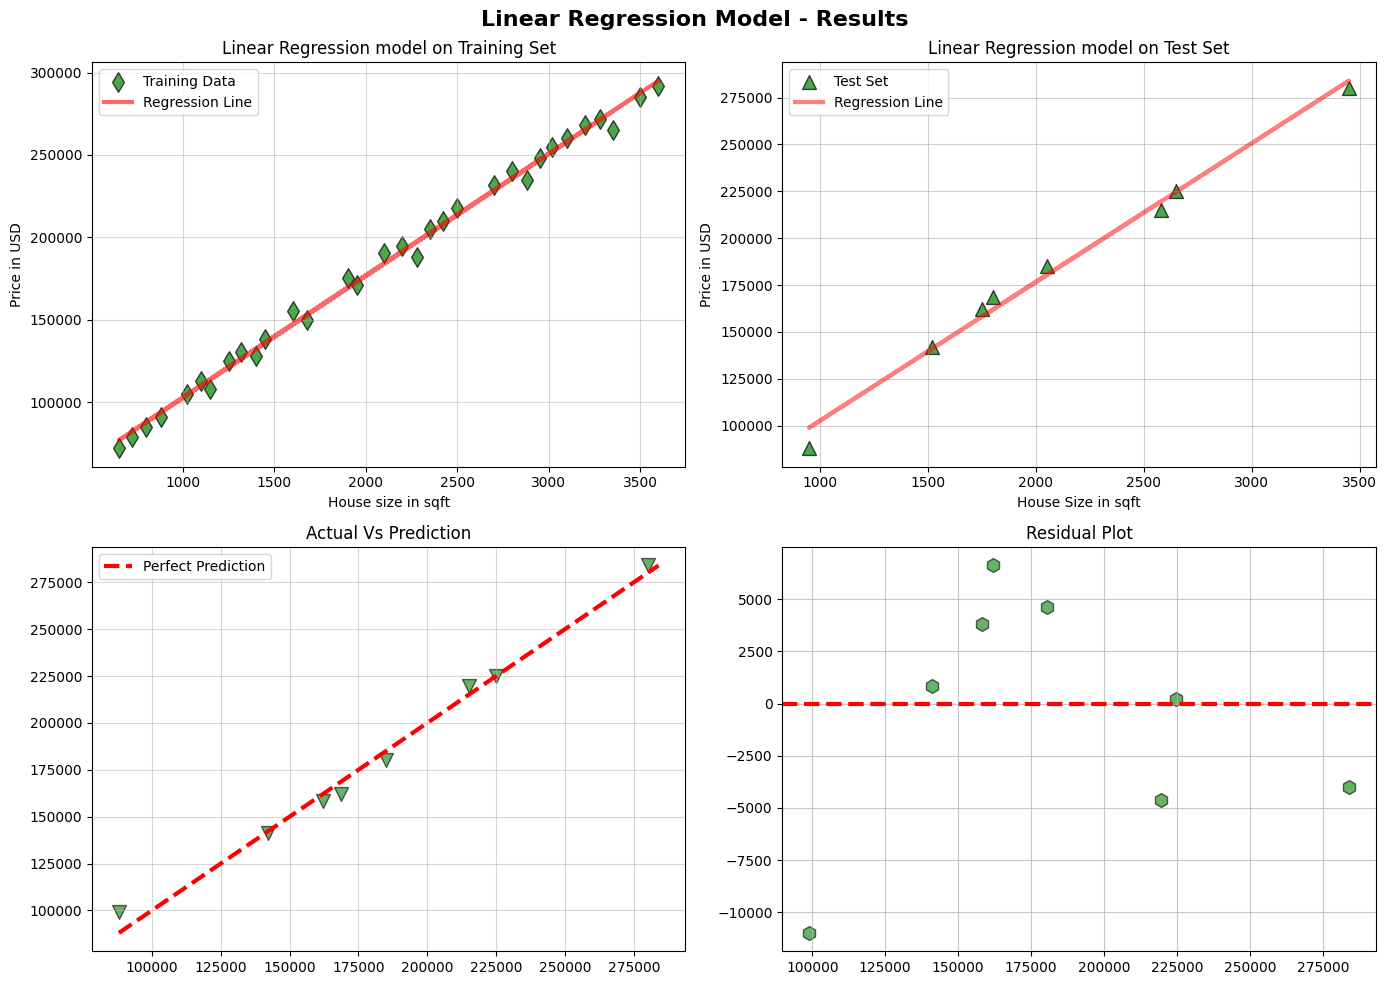

In [57]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
plt.suptitle('Linear Regression Model - Results', fontsize=16, fontweight='bold')

axes[0,0].scatter(X_train, y_train, label='Training Data',marker='d',s=100,edgecolor='black',color='green',alpha=0.7)
axes[0,0].plot(X_train,y_pred_train,linewidth=3,color='r',alpha=0.6,label='Regression Line')
axes[0,0].set_ylabel('Price in USD')
axes[0,0].set_xlabel('House size in sqft')
axes[0,0].set_title('Linear Regression model on Training Set')
axes[0,0].grid(True,alpha=0.5)
axes[0,0].legend()


axes[0,1].scatter(X_test, y_test, label='Test Set',marker='^',edgecolor='black',color='green',s=100,alpha=0.7)
axes[0,1].plot(X_test,y_pred_test,linewidth=3,alpha=0.5,color='r',label='Regression Line')
axes[0,1].set_ylabel('Price in USD')
axes[0,1].set_xlabel('House Size in sqft')
axes[0,1].set_title('Linear Regression model on Test Set')
axes[0,1].grid(True,alpha=0.6)
axes[0,1].legend()

axes[1,0].scatter(y_test,y_pred_test,marker='v',color='green',alpha=0.6,edgecolor='black',s=100)
min_value = min(y_test.min(),y_pred_test.min())
max_value = max(y_test.max(),y_pred_test.max())
axes[1,0].plot([min_value,max_value],[min_value,max_value],'r--',linewidth=3,label='Perfect Prediction')
axes[1,0].legend()
axes[1,0].set_title('Actual Vs Prediction')
axes[1,0].grid(True,alpha=0.5)

residuals = y_test - y_pred_test
axes[1,1].scatter(y_pred_test, residuals,marker='h',color='green',alpha=0.6,s=100, edgecolor='k')
axes[1,1].axhline(y=0,color='r', linestyle='--',linewidth=3)
axes[1,1].grid(True,alpha=0.7)
axes[1,1].set_title('Residual Plot')


plt.tight_layout()
plt.show()

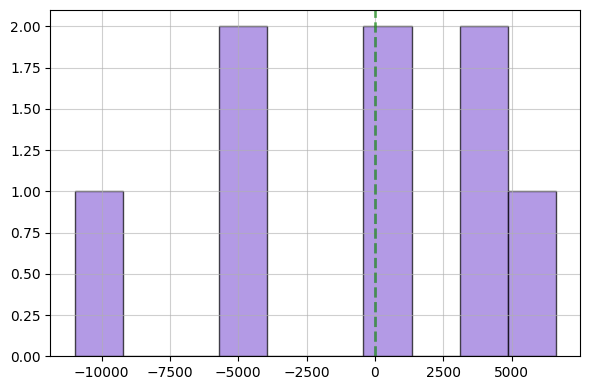

In [58]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=10,color='mediumpurple',edgecolor='k',alpha=0.7)
plt.axvline(x=0,color='green',linestyle='--',alpha=0.6,linewidth=2)
plt.grid(True,alpha=0.6)
plt.tight_layout()
plt.show()